In [35]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [36]:
#Loading and reading the dataset
df = pd.read_csv("aa_dataset-tickets-multi-lang-5-2-50-version.csv")

df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [37]:
#Keeping only what I need to use
df = df[['body', 'tag_1', 'priority', 'language']]

# Keep English only (simplifies NLP)
df = df[df['language'] == 'en']

# Remove missing values
df = df.dropna()

df.head()

,body,tag_1,priority,language
1,"Dear Customer Support Team,\n\nI am writing to...",Account,high,en
2,"Dear Customer Support Team,\n\nI hope this mes...",Product,medium,en
3,"Dear Customer Support Team,\n\nI hope this mes...",Billing,low,en
4,"Dear Support Team,\n\nI hope this message reac...",Product,medium,en
5,"Dear Customer Support,\n\nI hope this message ...",Feature,high,en


In [38]:
#Cleaning text
def clean_text(text):
  # lowercase
    text = text.lower()
    # remove symbols
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_text'] = df['body'].apply(clean_text)

In [39]:
#Converting text to numbers
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

In [40]:
#Creating 2 targets
# Model 1
y_category = df['tag_1']
# Model 2
y_priority = df['priority']

In [41]:
#Train-test split
X_train, X_test, y_cat_train, y_cat_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42
)

# Use same split for priority
_, _, y_pri_train, y_pri_test = train_test_split(
    X, y_priority, test_size=0.2, random_state=42
)

In [42]:
#Training the category model
model_category = MultinomialNB()
model_category.fit(X_train, y_cat_train)

MultinomialNB()

In [43]:
#Evaluating the category model
cat_predictions = model_category.predict(X_test)

print("Category Accuracy:", accuracy_score(y_cat_test, cat_predictions))
print(classification_report(y_cat_test, cat_predictions))

Category Accuracy: 0.6689106487148103
                                        precision    recall  f1-score   support

                               Account       0.00      0.00      0.00         7
                                 Alert       0.00      0.00      0.00         1
                                 Audio       0.00      0.00      0.00         1
                               Billing       0.91      0.71      0.80       161
                                   Bug       0.51      0.93      0.66       573
                              Business       0.00      0.00      0.00         1
                            Compliance       0.00      0.00      0.00         1
                         Configuration       0.00      0.00      0.00         1
                                 Crash       0.00      0.00      0.00        51
                              Customer       0.00      0.00      0.00         1
                      Customer Service       0.00      0.00      0.00         2
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
#Training the priority model
model_priority = MultinomialNB()
model_priority.fit(X_train, y_pri_train)

MultinomialNB()

In [45]:
#Evaluating the priority model
pri_predictions = model_priority.predict(X_test)

print("Priority Accuracy:", accuracy_score(y_pri_test, pri_predictions))
print(classification_report(y_pri_test, pri_predictions))

Priority Accuracy: 0.5021419828641371
              precision    recall  f1-score   support

        high       0.52      0.60      0.56      1265
         low       0.73      0.04      0.07       708
      medium       0.48      0.66      0.56      1295

    accuracy                           0.50      3268
   macro avg       0.58      0.43      0.40      3268
weighted avg       0.55      0.50      0.45      3268



In [46]:
#Testing
sample_text = ["My account is locked and I need urgent help"]

sample_clean = [clean_text(t) for t in sample_text]
sample_vector = vectorizer.transform(sample_clean)

predicted_category = model_category.predict(sample_vector)
predicted_priority = model_priority.predict(sample_vector)

print("Category:", predicted_category[0])
print("Priority:", predicted_priority[0])

Category: Bug
Priority: high


In [47]:
# Show sample predictions (comparison)

sample_results = pd.DataFrame({
    'Ticket Text': df['body'].iloc[-10:].values,
    'Actual Category': y_cat_test.iloc[:10].values,
    'Predicted Category': cat_predictions[:10],
    'Actual Priority': y_pri_test.iloc[:10].values,
    'Predicted Priority': pri_predictions[:10]
})

sample_results

,Ticket Text,Actual Category,Predicted Category,Actual Priority,Predicted Priority
0,There have been experienced unauthorized acces...,Feedback,Feedback,low,medium
1,"The data analytics tool encountered a crash, d...",Network,Bug,medium,medium
2,"Dear Customer Support, <br />We are encounteri...",Feedback,Feedback,medium,medium
3,A critical error has occurred during the data ...,Bug,Security,medium,medium
4,detected security breach in hospital IT systems,Security,Security,medium,medium
5,An unexpected billing discrepancy has been not...,Feature,Feature,medium,medium
6,"A data breach has occurred, which might be rel...",Security,Security,medium,medium
7,The data analytics tool experiences sluggish p...,Feedback,Feedback,medium,medium
8,Requesting an update on the integration featur...,Bug,Bug,low,high
9,Looking for detailed information on the projec...,Security,Security,high,high


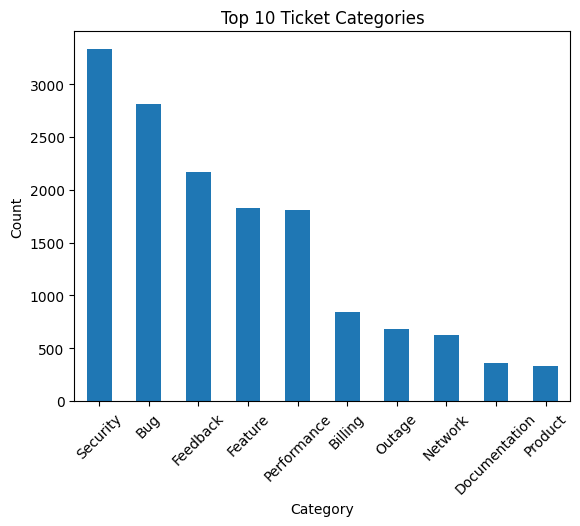

In [48]:
top_categories = df['tag_1'].value_counts().head(10)

top_categories.plot(kind='bar')
plt.title("Top 10 Ticket Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

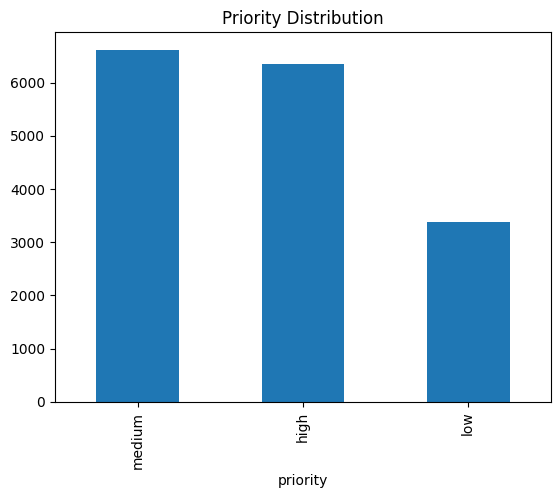

In [49]:
df['priority'].value_counts().plot(kind='bar', title="Priority Distribution")
plt.show()